# Transformer Embeddings

## Goal
Version 3 — use transformer embeddings directly from a pretrained model.
Unlike SBERT which is optimized for sentence similarity,
here we extract raw embeddings from a transformer and compare approaches.

## Question
How do different pooling strategies affect embedding quality?
CLS token vs mean pooling vs max pooling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel
import torch

## 1. Load Transformer Model

In [2]:
# Load tokenizer and model
model_name = "distilbert-base-uncased"

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

print(f"Done! Model loaded.")
print(f"Hidden size: {model.config.hidden_size}")

Loading distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done! Model loaded.
Hidden size: 768


## 2. Extract Embeddings with Different Pooling Strategies

In [3]:
def get_embeddings(texts: list, pooling: str = "mean") -> np.ndarray:
    """
    Extract embeddings from transformer model.

    Args:
        texts: List of input sentences
        pooling: "cls", "mean", or "max"

    Returns:
        numpy array of embeddings
    """
    embeddings = []

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt",
                          truncation=True, max_length=512, padding=True)
        with torch.no_grad():
            outputs = model(**inputs)

        hidden_states = outputs.last_hidden_state

        if pooling == "cls":
            embedding = hidden_states[:, 0, :].squeeze().numpy()
        elif pooling == "mean":
            attention_mask = inputs["attention_mask"]
            mask_expanded = attention_mask.unsqueeze(-1).float()
            embedding = (hidden_states * mask_expanded).sum(1) / mask_expanded.sum(1)
            embedding = embedding.squeeze().numpy()
        elif pooling == "max":
            embedding = hidden_states.squeeze().max(dim=0).values.numpy()

        embeddings.append(embedding)

    return np.array(embeddings)

print("Function defined.")
print("Pooling strategies: CLS, Mean, Max")

Function defined.
Pooling strategies: CLS, Mean, Max


## 3. Compare Pooling Strategies

In [4]:
sentences = [
    "Machine learning models learn from data",
    "AI systems improve through training on examples",
    "Algorithms extract patterns from datasets",
    "The weather today is sunny and warm",
    "It is a beautiful clear day outside",
    "The sky is bright and the temperature is high",
    "I love eating pizza and pasta",
    "Italian cuisine is my favorite food",
    "Nothing beats a good slice of pizza",
]

# Compute embeddings for each pooling strategy
print("Computing embeddings...")
results = {}
for pooling in ["cls", "mean", "max"]:
    embeddings = get_embeddings(sentences, pooling=pooling)
    sim_matrix = cosine_similarity(embeddings)
    results[pooling] = sim_matrix
    print(f"{pooling} pooling: done")

print("\nAll done!")

Computing embeddings...
cls pooling: done
mean pooling: done
max pooling: done

All done!


## 4. Visualize Comparison

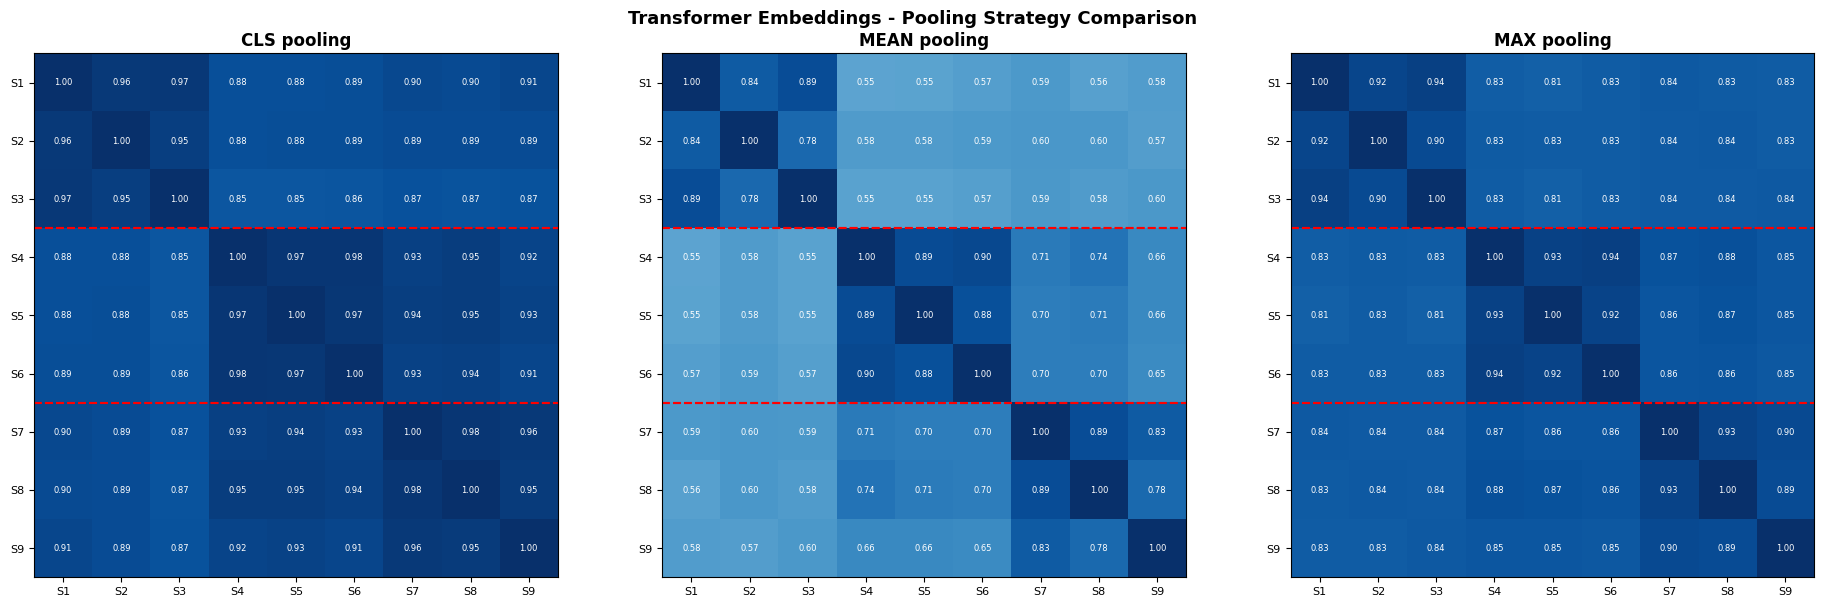

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
labels = [f"S{i+1}" for i in range(len(sentences))]

for ax, (pooling, sim_matrix) in zip(axes, results.items()):
    im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(sentences)))
    ax.set_yticks(range(len(sentences)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    for i in range(len(sentences)):
        for j in range(len(sentences)):
            ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
                   ha="center", va="center", fontsize=6,
                   color="white" if sim_matrix[i,j] > 0.5 else "black")
    
    for line in [2.5, 5.5]:
        ax.axhline(line, color="red", linewidth=1.5, linestyle="--")
        ax.axhline(line, color="red", linewidth=1.5, linestyle="--")

    ax.set_title(f"{pooling.upper()} pooling", fontsize=12, fontweight="bold")

plt.suptitle("Transformer Embeddings - Pooling Strategy Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("transformer_pooling_comparison.png", dpi=300)
plt.show()

## 5. Key Observations

| Pooling | Within-Group Avg | Between-Group Avg | Discrimination |
|---------|-----------------|-------------------|----------------|
| CLS | ~0.96 | ~0.89 | Weak |
| MEAN | ~0.87 | ~0.57 | Strong |
| MAX | ~0.92 | ~0.83 | Moderate |

## Key Insight
MEAN pooling is the best strategy for semantic similarity.
It averages all token embeddings — capturing the full sentence meaning.

CLS token was designed for classification tasks, not similarity.
It captures a global sentence representation but loses fine-grained meaning.

## SBERT vs Raw Transformer
SBERT uses MEAN pooling AND fine-tuning on sentence pairs.
Raw transformer with MEAN pooling is good but not as precise.
Fine-tuning makes the difference.

## Next
-> 04_comparison.ipynb — full comparison of all three versions.